<a href="https://colab.research.google.com/github/aka-iriska/text_classification/blob/main/solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Классификация веб-контента: От базовых методов к Deep Learning

Идея: провести сравнительный анализ разных подходов в задаче детекции "запрещенных" сайтов.

Описание задачи: задача состоит в бинарной классификации веб-страниц по их URL и заголовкам.
Нам нужно отделить безопасный контент от категории "для взрослых".

## Data

Данные для проекта взяты из закрытого соревнования. Исходные файлы (train.csv, test.csv) не включены в репозиторий. Вы можете найти их по ссылке: [Porn detection dataset](https://www.kaggle.com/datasets/dulinaira/porn-detection-dataset).

Распакуйте их в папку `/data` в корне проекта.

Или скачайте данные из гугл диска:

In [1]:
!pip install pandas scikit-learn fasttext-wheel nltk jupyterlab sentence-transformers torch matplotlib seaborn scipy-stubs ipywidgets datasets

In [2]:
import gdown
import os

folder_id = '1RD7s9F2sxg6z_QYxzQHiPxrmtaxzM_rt'

# Параметр use_cookies=False помогает избежать проблем с авторизацией
gdown.download_folder(id=folder_id, output='data', quiet=False, use_cookies=False)

print("Все файлы из папки скачаны в /data")

Retrieving folder contents


Processing file 1v2KpV0t9b5TKGDPN3q8P4cmazfJvk7eT sample_submission.csv
Processing file 1hvA5KmAzr18Ck3VDtofqlztJF_QSqheA test.csv
Processing file 11HXctAInKullrsIGwHGBnQvwZOGgiZDs train.csv
Processing file 1AnkBGvoeyq6Kq0LPKl3PVMerAlegjorI truth2.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1v2KpV0t9b5TKGDPN3q8P4cmazfJvk7eT
To: /content/data/sample_submission.csv
100%|██████████| 1.49M/1.49M [00:00<00:00, 122MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hvA5KmAzr18Ck3VDtofqlztJF_QSqheA
To: /content/data/test.csv
100%|██████████| 22.5M/22.5M [00:00<00:00, 116MB/s] 
Downloading...
From: https://drive.google.com/uc?id=11HXctAInKullrsIGwHGBnQvwZOGgiZDs
To: /content/data/train.csv
100%|██████████| 18.6M/18.6M [00:00<00:00, 136MB/s]
Downloading...
From: https://drive.google.com/uc?id=1AnkBGvoeyq6Kq0LPKl3PVMerAlegjorI
To: /content/data/truth2.csv
100%|██████████| 2.76M/2.76M [00:00<00:00, 79.4MB/s]

Все файлы из папки скачаны в /data



Download completed


## EDA (exploratory data analysis)

Посмотрим на изначальный датасет:

In [3]:
import pandas as pd

training_ds = "data/train.csv"

train_df = pd.read_csv(training_ds)
train_df.head()

,ID,url,title,label
0,0,m.kp.md,"Экс-министр экономики Молдовы - главе МИДЭИ, ц...",0
1,1,www.kp.by,Эта песня стала известна многим телезрителям б...,0
2,2,fanserials.tv,Банши 4 сезон 2 серия Бремя красоты смотреть о...,0
3,3,colorbox.spb.ru,Не Беси Меня Картинки,0
4,4,tula-sport.ru,В Новомосковске сыграют следж-хоккеисты алекси...,0


In [4]:
train_df.shape

(135309, 4)

In [5]:
train_df['label'].value_counts()

,count
label,
0,118594
1,16715


Особенности данных: мы имеем дело с сильно несбалансированной выборкой и короткими текстовыми фрагментами (заголовки, домены).

Поэтому чтобы улучшать метрики моделей, мы будем насильно штрафовать их за ошибки ещё больше раз, для этого хардкорно продублируем данные с меткой label = 1 ещё 4 раза:

In [6]:
minority_class = train_df[train_df['label'] == 1]
print(minority_class.head())

oversampled_data = pd.concat([train_df, minority_class, minority_class, minority_class, minority_class, minority_class, minority_class], axis=0)

# Перемешиваем данные
train_df_balanced = oversampled_data.sample(frac=1, random_state=42).reset_index(drop=True)

    ID             url                                              title  \
8    8       xlecx.com  league of legends » Page 5 » Porn comics free ...   
12  12   pornmult.info  кримпай,мать и сын » Страница 5 » смотреть пор...   
19  19  24eropixel.net  Мужик поставил блондинку раком и отодрал ее ту...   
21  21   gdespaces.com  Порно которое ты искал / Видео - Spaces.ru / S...   
41  41     hdxclub.com  Лесбийский секс с кунилингусом двух стройных с...   

    label  
8       1  
12      1  
19      1  
21      1  
41      1  


In [7]:
print(f"Было строк: {len(train_df)}")
print(f"Стало строк после дублирования: {len(train_df_balanced)}")
print(f"Распределение классов: {train_df_balanced['label'].value_counts(0)}")

Было строк: 135309
Стало строк после дублирования: 235599
Распределение классов: label
0    118594
1    117005
Name: count, dtype: int64


In [8]:
train_df = train_df_balanced

In [9]:
# Тестовая выборка
test_df = pd.read_csv("data/test.csv")
truth_df = pd.read_csv("data/truth2.csv")
test_df['true_label'] = truth_df['label']

In [10]:
test_df.head()

,ID,url,title,true_label
0,135309,www.kommersant.ru,Шестой кассационный суд в Самаре начнет работу...,0
1,135310,urexpert.online,"Что такое индексация алиментов, кем и в каких ...",0
2,135311,imperimeha.ru,Женщинам | Империя Меха - Part 12,0
3,135312,national-porn.com,"Небритые, волосатые киски: Порно всех стран и ...",1
4,135313,2gis.ru,67,0


Подготовим функции для дальнейшей обработки результатов.

1) Метрики

In [11]:
def accuracy_sc(*, tp, tn, fp, fn):
    return (tp + tn) / (tp + tn + fp + fn)
def precision_sc(*, tp, fp):
    return tp / (tp + fp + 1e-9)
def recall_sc(*, tp, fn):
    return tp / (tp + fn + 1e-9)

def f1_sc(*, precision, recall):
    return 2 * (precision * recall) / (precision + recall + 1e-9)

2. Тепловая карта

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs("plots", exist_ok=True)  # создаст папку если её нет

def plot_confusion(y_true, y_pred, model_name, filename):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ["d", ".2%"],
        ["Абсолютные значения", "Нормализованная"]
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues", ax=ax,
                    xticklabels=["Обычный", "Взрослый"],
                    yticklabels=["Обычный", "Взрослый"])
        ax.set_title(f"{model_name} — {title}")
        ax.set_xlabel("Предсказание")
        ax.set_ylabel("Истина")

    plt.tight_layout()
    plt.savefig(f"plots/{filename}", dpi=150, bbox_inches="tight")
    plt.show()

3. Вывод ошибок

In [13]:
def analyze_errors(test_df, true_col, pred_col, model_name, n_samples=10, random_state=42):
    """
    Анализ ошибок модели: статистика + случайные примеры.
    :param test_df: датафрейм с предсказаниями
    :param true_col: название колонки с истинными метками
    :param pred_col: название колонки с предсказаниями модели
    :param model_name: строка для заголовка вывода
    :param n_samples: сколько случайных ошибок показать
    """
    errors_df = test_df[test_df[pred_col] != test_df[true_col]]

    # Разбивка по типу ошибки
    fn = errors_df[errors_df[true_col] == 1]  # был взрослый, сказал обычный
    fp = errors_df[errors_df[true_col] == 0]  # был обычный, сказал взрослый

    print(f"{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(f"Всего ошибок:         {len(errors_df)} из {len(test_df)} примеров")
    print(f"  False Negative (пропустил взрослый): {len(fn)}")
    print(f"  False Positive (лишний флаг):        {len(fp)}")
    print()

    sample = errors_df.sample(min(n_samples, len(errors_df)), random_state=random_state)
    for idx, row in sample.iterrows():
        text = f"{row.get('title', '')} | {row.get('url', '')}"
        true_label = "взрослый" if row[true_col] == 1 else "обычный"
        pred_label = "взрослый" if row[pred_col] == 1 else "обычный"
        error_type = "FN" if row[true_col] == 1 else "FP"

        print(f"[{error_type}] {text}")
        print(f"     Истина: {true_label} | Предсказано: {pred_label}")
        print(f"{'-'*60}")
    print()

## TF-IDF

### Препроцессинг

In [14]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

# Загружаем стоп-слова (предлоги, союзы и т.д., которые не несут смысла)
nltk.download('stopwords')
stop_words = set(stopwords.words('russian')).union(set(stopwords.words('english')))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
import re

boring_tlds = {'ru', 'com', 'net', 'org', 'by', 'md', 'ua', 'online', 'spb'}

def process_url(url):
    url = str(url).lower()
    # Убираем протоколы и www в начале
    url = re.sub(r'^(https?://)?(www\.)?', '', url)
    domain = url.split('/')[0]
    # Разбиваем домен на части по точкам
    pieces = domain.split('.')
    return [p for p in pieces if p not in boring_tlds and len(p) >= 3]

In [16]:
import re

def process_title(title):
    tokens = re.findall(r'[а-яёa-zA-Z]{3,}', str(title).lower())
    return [t for t in tokens if t not in stop_words]

Очищаем обучающую выборку

In [17]:
train_url_clean = train_df['url'].apply(lambda x: ' '.join(process_url(str(x))))
train_title_clean = train_df['title'].apply(lambda x: ' '.join(process_title(str(x))))

Очищаем тестовую выборку

In [18]:
test_url_clean = test_df['url'].apply(lambda x: ' '.join(process_url(str(x))))
test_title_clean = test_df['title'].apply(lambda x: ' '.join(process_title(str(x))))

Создаем два отдельных векторизатора для `url` и для `title`

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_url = TfidfVectorizer(max_features=50000)
vectorizer_title = TfidfVectorizer(max_features=100000, ngram_range=(1, 2))

Векторизируем url

In [44]:
X_train_url = vectorizer_url.fit_transform(train_url_clean)
X_test_url  = vectorizer_url.transform(test_url_clean)

Векторизируем title

In [45]:
X_train_title = vectorizer_title.fit_transform(train_title_clean)
X_test_title  = vectorizer_title.transform(test_title_clean)

Интересно посмотреть на самые редкие слова

In [46]:
idf_df = pd.DataFrame({'word': vectorizer_title.get_feature_names_out(),
                       'idf_weight': vectorizer_title.idf_})

print("Самые редкие слова:")
print(idf_df.sort_values(by='idf_weight', ascending=False).head(10))

print("\nСамые частотные слова (низкий IDF):")
print(idf_df.sort_values(by='idf_weight', ascending=True).head(10))


Самые редкие слова:
                      word  idf_weight
44939          ursus icons   12.676744
76071   освещенность диска   12.271278
1456               amp amp   12.271278
60534                ерлан   12.271278
72857            наступила   12.271278
76070         освещенность   12.271278
46839  warhammer warhammer   11.983596
78398            печь соло   11.983596
14938             film zle   11.983596
44143                 tsum   11.983596

Самые частотные слова (низкий IDF):
            word  idf_weight
81044      порно    3.026311
33355       porn    3.351424
53991      видео    3.356025
75339     онлайн    3.400194
51248  бесплатно    3.811503
89329   смотреть    3.876931
39166        sex    3.887921
45829     videos    3.966371
88597    скачать    4.019788
8638         com    4.083701


Склеиваем (hstack) матрицы признаков по горизонтали

In [47]:
from scipy.sparse import hstack

X_train_combined = hstack([X_train_url, X_train_title])
X_test_combined  = hstack([X_test_url, X_test_title])

### Обучение

In [48]:
all_feature_names = list(vectorizer_url.get_feature_names_out()) + list(vectorizer_title.get_feature_names_out())

row = X_train_combined[0]

word_values = [
    (all_feature_names[i], row.data[idx])
    for idx, i in enumerate(row.indices)
]

word_values.sort(key=lambda x: x[1], reverse=True)

for word, score in word_values:
    print(f"Слово: {word:20} | Вес TF-IDF: {score:.4f}")

Слово: fullxxxmovies        | Вес TF-IDF: 1.0000
Слово: stepmom caught       | Вес TF-IDF: 0.5045
Слово: caught wanking       | Вес TF-IDF: 0.5045
Слово: wanking              | Вес TF-IDF: 0.4593
Слово: stepmom              | Вес TF-IDF: 0.3741
Слово: caught               | Вес TF-IDF: 0.3741


Что мы имеем? Огромную матрицу one-hot encoded, где присутствие слова в тексте кодируется его TF-IDF весом.

Обучать будем на такой матрице базовую модель - логистическую регрессию. Причины:
* В отличие от FastText или BERT, в логистической регрессии мы можем четко увидеть веса каждого слова и понять, почему модель приняла то или иное решение.
* Интересно будет в конце сравнить классический алгоритм с FastText и BERT.

In [49]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)#, class_weight='balanced')

In [50]:
%%time

lr_model.fit(X_train_combined, train_df['label'])

CPU times: user 7.6 s, sys: 5.83 ms, total: 7.61 s
Wall time: 3.94 s


LogisticRegression(max_iter=1000, random_state=42)

### Предсказание

In [51]:
y_pred_tf_idf = lr_model.predict(X_test_combined)

In [52]:
test_df['tfidf_label'] = y_pred_tf_idf

### Метрики

In [54]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(test_df['true_label'], y_pred_tf_idf).ravel()
accuracy = accuracy_sc(tp=tp, tn=tn, fp=fp, fn=fn)
precision = precision_sc(tp=tp, fp=fp)
recall = recall_sc(tp=tp, fn=fn)
f1 = f1_sc(precision=precision, recall=recall)

tfidf_results = {
    'Model': 'TF-IDF + LogReg',
    'Accuracy': round(accuracy, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1-score': round(f1, 4)
}

results_table = pd.DataFrame([tfidf_results])
display(results_table) # 0.972

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + LogReg,0.9931,0.9705,0.9736,0.972


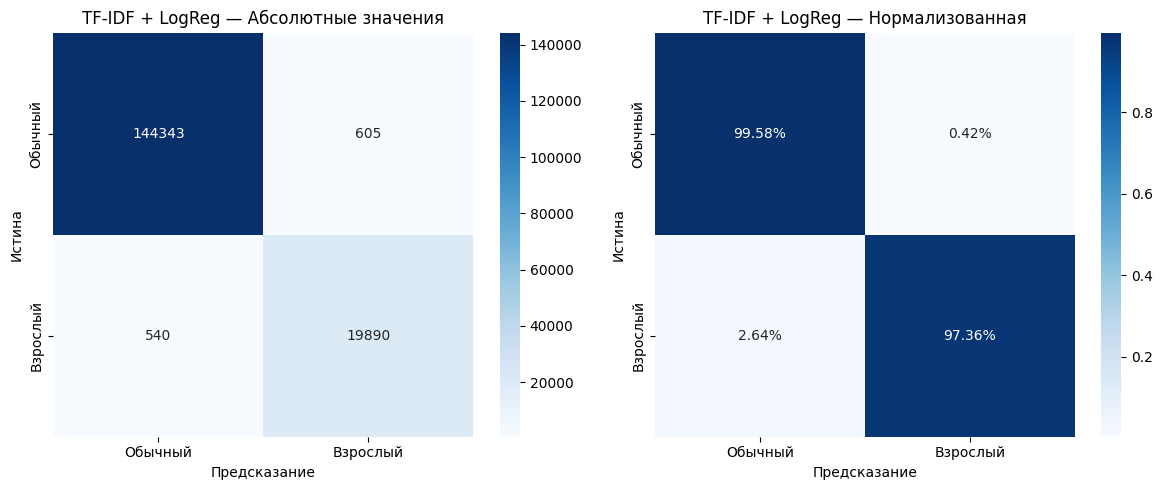

In [55]:
plot_confusion(test_df['true_label'], y_pred_tf_idf, "TF-IDF + LogReg", "cm_tfidf.png")

In [56]:
analyze_errors(test_df, "true_label", "tfidf_label", "TF-IDF + LogReg")

  TF-IDF + LogReg
Всего ошибок:         1145 из 165378 примеров
  False Negative (пропустил взрослый): 540
  False Positive (лишний флаг):        605

[FP] 101 | ftopx.com
     Истина: обычный | Предсказано: взрослый
------------------------------------------------------------
[FP] Ներողություն եմ խնդրում մայրերից. քառօրյայի մասնակիցը պատշաճ վերաբերմունք է պահանջում իշխանությունից - BarevHayer | barevhayer.am
     Истина: обычный | Предсказано: взрослый
------------------------------------------------------------
[FN] Salope en chaleur enfonce une brosse pour wc dans sa chatte rasée - ElleSalope.com | ellesalope.com
     Истина: взрослый | Предсказано: обычный
------------------------------------------------------------
[FN] Just a moment... | udll.eu
     Истина: взрослый | Предсказано: обычный
------------------------------------------------------------
[FN] Елена, 28 Скорпион, Москва | lisi23d263 | love.bisexy.ru | love.bisexy.ru
     Истина: взрослый | Предсказано: обычный
--------

**ВЫВОД**:

Ключевые особенности реализации:

- Использован раздельный подход к обработке признаков: колонки URL и Title обрабатывались независимыми векторизаторами, после чего объединялись в единую разреженную матрицу через hstack. Это позволило модели учитывать разную значимость слов в адресе сайта и в его заголовке.
- Включение n-грамм (размером от 1 до 2 слов) позволило модели улавливать устойчивые словосочетания, повысив тем самым точность на специфических тематиках.

Результаты:

-  F1-score (Macro) на тестовой выборке составил `0.972`.
- Accuracy модели: `0.9931`.
- Количество ошибок: `1145`

Наблюдения и анализ ошибок:

- Модель показала отличные результаты в выявлении характерных слов-маркеров, благодаря их высокому весу в TF-IDF.
- При анализе ошибок (Error Analysis) было выявлено, что модель иногда ошибается на очень коротких заголовках, где TF-IDF веса недостаточно велики для уверенного решения.
- Также обнаружены случаи «шума» в исходной разметке данных, где модель верно классифицировала подозрительный контент, хотя в разметке он был помечен как безопасный.

## FastText

In [57]:
import fasttext

FastText - библиотека для обучения векторных представлений слов и классификации текста, созданная лабораторией AI Research (FAIR) Facebook.

Она разделяет слова на n-граммы, а векторное представление самого слова вычисляет как сумму ембеддингов этих n-грамм.

### Препроцессинг

In [58]:
# Объединяем URL и заголовок в один текст (фичи)
X_train = train_df['url'].fillna('') + ' ' + train_df['title'].fillna('')

# таргет
y_train = train_df['label']

Разрезаем длинные строки на слова (токены), а также применяем снова леммитизацию, чтобы разные формы одно и того же слова относились к одному понятию:

In [59]:
import re

def tokenizer(text):
    text = text.lower()

    parts = text.split(' ', 1) # url and title
    url_part = parts[0]
    title_part = parts[1] if len(parts) > 1 else ""

    # В заголовке разрешаем слова от 3 символов
    tokens = process_url(url_part) + process_title(title_part)

    final_tokens = [t for t in tokens]

    return final_tokens

Для FastTest нужно привести метки к виду `__label__<n>`

In [60]:
# подготовим файлы с датасетами для фасттекста
train_df["label_ft"] = train_df["label"].apply(lambda x: "__label__" + str(x))
train_df.head()

,ID,url,title,label,label_ft
0,39864,fullxxxmovies.net,My Stepmom Caught Me Wanking (2017),1,__label__1
1,127592,simhost.org,Гайд по Idle Heroes - советы для новичков » SI...,0,__label__0
2,23677,adultxxxarea.com,Busty lesbian pornstars Whitney Westgate and C...,1,__label__1
3,17234,formulaire-dc4.info,No sex but beauty - Adult videos,1,__label__1
4,97109,mover.uz,Agust D (Suga) ‘Give it to me’ Choreography x ...,0,__label__0


In [61]:
X_train_clean = X_train.apply(lambda x: ' '.join(tokenizer(str(x))))

In [62]:
X_train[:5], X_train_clean[:5]

(0    fullxxxmovies.net My Stepmom Caught Me Wanking...
 1    simhost.org Гайд по Idle Heroes - советы для н...
 2    adultxxxarea.com Busty lesbian pornstars Whitn...
 3    formulaire-dc4.info No sex but beauty - Adult ...
 4    mover.uz Agust D (Suga) ‘Give it to me’ Choreo...
 dtype: object,
 0                 fullxxxmovies stepmom caught wanking
 1    simhost гайд idle heroes советы новичков simho...
 2    adultxxxarea busty lesbian pornstars whitney w...
 3          formulaire-dc4 info sex beauty adult videos
 4    mover agust suga give choreography hope street...
 dtype: object)

In [63]:
train_ds = pd.concat([X_train_clean.apply(lambda x: re.sub('\t', '', x)),
                           y_train.apply(lambda x: '__label__' + str(x))], axis=1)

`train_ds` — это просто таблица (DataFrame).
Чтобы FastText начал учиться, эту таблицу нужно сохранить в текстовый файл без лишних кавычек и запятых.

In [64]:
import os
os.makedirs("fasttext", exist_ok=True)

train_ds.to_csv("fasttext/train_ds.txt", sep='\t', header=None, index=None)

In [65]:
with open("fasttext/train_ds.txt", "r", encoding="utf-8") as f:
    for _ in range(5): # Выведет первые 5 строк
        print(f.readline().strip())

fullxxxmovies stepmom caught wanking	__label__1
simhost гайд idle heroes советы новичков simhost новости статьи играх кино сериала подкасты игровые сервера	__label__0
adultxxxarea busty lesbian pornstars whitney westgate catie parker free nude big tit adult xxx area	__label__1
formulaire-dc4 info sex beauty adult videos	__label__1
mover agust suga give choreography hope street музыка move	__label__0


### Обучение

In [66]:
%%time
ft_model = fasttext.train_supervised(
    input="fasttext/train_ds.txt",
    epoch=14,
    lr = 0.4,
    # minCount=5,  # отсеиваем редкие токены
    minn=3, maxn=6,  # диапазон для символьных нграмм
    wordNgrams=5,  # используем словесные нграммы размера 2
    dim=45,  # размер вектора для каждого слова/кусочка
    bucket=350000, # количество бакетов для хеширования, услоно на что делится хэш
    #loss='ova', # sigmoid
) # логи обучения пишутся в терминале

CPU times: user 1min 9s, sys: 410 ms, total: 1min 10s
Wall time: 1min 10s


### Предсказание

In [67]:
X_final = (test_df['url'].fillna('') + ' ' + test_df['title'].fillna(''))
X_final = X_final.apply(lambda x: ' '.join(tokenizer(str(x)))).tolist()

Наконец предсказываем

In [68]:
# k=1 - берем только один самый вероятный класс
labels, predictions = ft_model.predict(X_final, k=1)

In [69]:
print(labels[0], predictions[0])

['__label__0'] [0.99999297]


In [70]:
test_df['ft_label'] = [int(l[0].replace('__label__', '')) for l in labels]

Собираем метрики с тестовой выборки

In [71]:
y_true = test_df['true_label']
y_pred = test_df['ft_label']

In [73]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

precision = precision_sc(tp = tp, fp=fp)
recall = recall_sc(tp=tp, fn=fn)
fasttext_metrics = {
    'Model': 'FastText',
    'Accuracy': round(accuracy_sc(tp=tp, tn=tn, fp=fp, fn=fn), 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1-score': round(f1_sc(precision = precision, recall = recall), 4)
}

results_table = pd.DataFrame([fasttext_metrics])
# Выводим красивую итоговую таблицу
display(results_table) # 0.9877

,Model,Accuracy,Precision,Recall,F1-score
0,FastText,0.997,0.9901,0.9854,0.9877


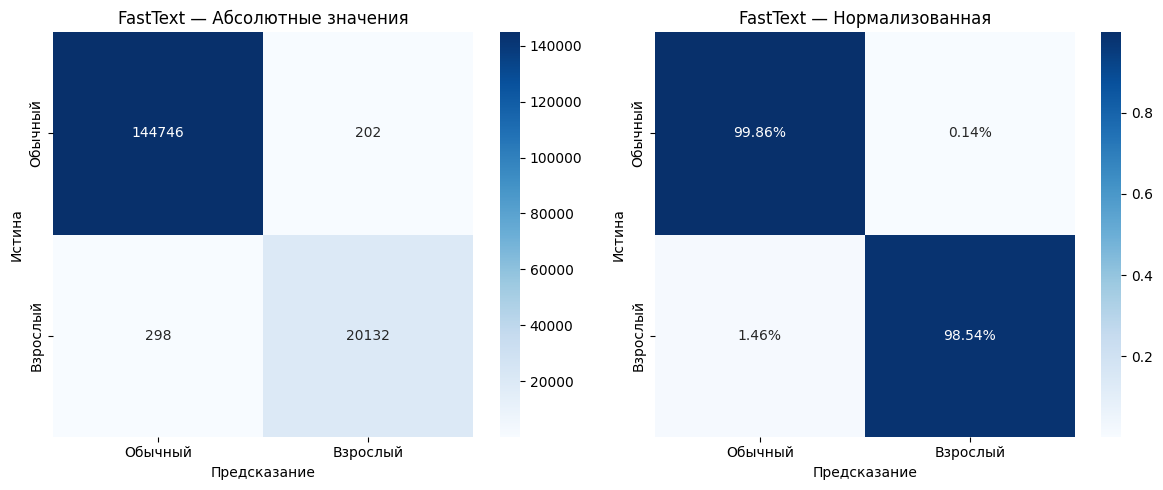

In [74]:
plot_confusion(test_df['true_label'], test_df['ft_label'], "FastText", "cm_fasttext.png")

In [88]:
analyze_errors(test_df, "true_label", "ft_label", "FastText", n_samples=15, random_state=17)

  FastText
Всего ошибок:         500 из 165378 примеров
  False Negative (пропустил взрослый): 298
  False Positive (лишний флаг):        202

[FP] туалет эротика - 23 тыс. результатов. Поиск Mail.Ru | mail.ru
     Истина: обычный | Предсказано: взрослый
------------------------------------------------------------
[FN] Tag miya-khalifa | x24.video
     Истина: взрослый | Предсказано: обычный
------------------------------------------------------------
[FN] утро с минета - Поиск Mail.Ru | mail.ru
     Истина: взрослый | Предсказано: обычный
------------------------------------------------------------
[FP] ST об Oxxxymiron: "Позиционирует себя как интеллектуал, но за всем этим скрывается фуфел" | the-flow.ru
     Истина: обычный | Предсказано: взрослый
------------------------------------------------------------
[FN] Fair tests examples | gykagoru10.lasnil.ru.net
     Истина: взрослый | Предсказано: обычный
------------------------------------------------------------
[FP] Embed Player | 

In [91]:
analyze_errors(test_df, "true_label", "ft_label", "FastText", n_samples=6, random_state=9)

  FastText
Всего ошибок:         500 из 165378 примеров
  False Negative (пропустил взрослый): 298
  False Positive (лишний флаг):        202

[FN] гибкая секс - Поиск Mail.Ru | mail.ru
     Истина: взрослый | Предсказано: обычный
------------------------------------------------------------
[FP] отчим трахает дочку дашу - 510 тыс. результатов. Поиск Mail.Ru | mail.ru
     Истина: обычный | Предсказано: взрослый
------------------------------------------------------------
[FP] FutureBanking: Упростил ли PayPass отдых гостям фестиваля Alfa Future People? | futurebanking.ru
     Истина: обычный | Предсказано: взрослый
------------------------------------------------------------
[FN] Соблазнение жмж видео | bopabikers.com
     Истина: взрослый | Предсказано: обычный
------------------------------------------------------------
[FN] Гей видео студенты - Лучшее гей видео | gei1-video-studenty1.goroskopswzdeyw.appspot.com
     Истина: взрослый | Предсказано: обычный
---------------------------

**ВЫВОД:**

В ходе работы была обучена модель FastText в режиме обучения с учителем (supervised). Главное преимущество данного метода — работа не только с целыми словами, но и с символьными n-граммами (подсловами), что дает устойчивость к опечаткам и позволяет обрабатывать слова, которых не было в обучающей выборке.

Метрики качества:
- F1-score: `0.9877`
- Accuracy: `0.997`
- Кол-во ошибок: `500`

Анализ:

- Модель ошибочно классифицировала новостную статью сайта Glavred, или Elle, или Russia TV как «взрослый контент» (False Positive). Это произошло из-за высокой концентрации слов-маркеров. FastText, работая на уровне n-грамм, видит эти слова, но не учитывает общий новостной контекст статьи. Это ограничение «мешка слов» — модель не понимает, что текст описывает событие, а не предоставляет сам контент.

- Шум и спорная разметка данных (Data Quality):
    В нескольких примерах модель предсказала класс 1 (NSFW), в то время как в истинной разметке стоял класс 0. Анализируя текст, можно сделать вывод, что модель оказалась точнее разметки. В данных присутствует заметный шум, что искусственно занижает итоговые метрики модели.

- Проблема коротких текстов и отсутствие данных:
    Примеры с заголовками типа «60» или «153» модель относит к безопасному классу, даже если домен является сомнительным (3gpjizz.mobi). При отсутствии содержательного текста модели катастрофически не хватает n-грамм для принятия решения.

Итоговое мнение: FastText показал отличную способность находить закономерности в самих словах и их частях. Однако для отделения «новостей о контенте» от «самого контента» модели недостаточно семантического понимания, что является точкой роста для использования более тяжелых моделей (например, BERT).

## BERT (fine-tuning)

**BERT** - Bidirectional Encoder Representations from Transformers. В отличие от предыдущих методов, BERT учитывает порядок слов и их взаимосвязи. В отличие от тех же RNN transformers используют метод attention и принимают во внимание всё предложение целиком, а не слово за словом. Если быть точнее, то всё благодаря двунаправленности (Bidirectional), BERT на каждом слое видит одновременно и левый, и правый контекст слова. Это позволяет ему различать тонкие нюансы: например, понять, что новость на «Главреде» — это журналистика, а не порнография, просто по структуре предложений и контекстуальным связям слов.

Мы проведем Fine-tuning — дообучим предобученную на миллионах текстов модель именно под нашу специфику (классификация URL и заголовков).

In [92]:
from transformers import AutoTokenizer

model_name = "bert-base-multilingual-cased"#"cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


### Препроцессинг

Снова выделим из обучающей выборки валидационную:

In [93]:
from sklearn.model_selection import train_test_split

train_sub, val_sub = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

In [94]:
def tokenize_function(examples):
    # Склеиваем url и title, как делали раньше
    texts = [f"{t} {u}" for t, u in zip(examples["title"], examples["url"])]
    return tokenizer(texts, padding="max_length", truncation=True, max_length=128)

Создаем объекты Dataset из pandas

In [95]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_sub[['title', 'url', 'label']])
val_ds = Dataset.from_pandas(val_sub[['title', 'url', 'label']])

tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_val = val_ds.map(tokenize_function, batched=True)

tokenized_test = Dataset.from_pandas(test_df).map(tokenize_function, batched=True)

Map:   0%|          | 0/188479 [00:00<?, ? examples/s]

Map:   0%|          | 0/47120 [00:00<?, ? examples/s]

Map:   0%|          | 0/165378 [00:00<?, ? examples/s]

### Обучение

In [96]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

b_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Гиперпараметры
training_args = TrainingArguments(
    output_dir="./bert_results",
    learning_rate=2e-5, # рекомендации самих авторов BERT из Google
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01, # регуляризация
    eval_strategy="epoch", # провекра после каждой эпохи
    save_strategy="no",
    report_to="none"
)
trainer = Trainer(
    model=b_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
)

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
%%time

trainer.train()

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss
1,0.015586,0.013597


### Предсказание

In [ ]:
# Получаем предсказания
predictions = trainer.predict(tokenized_test)

In [ ]:
import numpy as np

y_pred_bert = np.argmax(predictions.predictions, axis=-1)

In [ ]:
test_df['bert_label'] = y_pred_bert

Собираем метрики с тестовой выборки

In [ ]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(test_df['true_label'], y_pred_bert).ravel()

precision = precision_sc(tp = tp, fp=fp)
recall = recall_sc(tp=tp, fn=fn)
bert_metrics = {
    'Model': 'BERT',
    'Accuracy': round(accuracy_sc(tp=tp, tn=tn, fp=fp, fn=fn), 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1-score': round(f1_sc(precision = precision, recall = recall), 4)
}

results_table = pd.DataFrame([bert_metrics])

display(results_table)

In [ ]:
plot_confusion(test_df['true_label'], y_pred_bert, "BERT", "cm_bert.png")

In [ ]:
analyze_errors(test_df, "true_label", "bert_label", "BERT", n_samples=15, random_state=77)

**ВЫВОД**:

Метрики качества:
- F1-score: `0.9819`
- Accuracy: `0.9956`
- Кол-во ошибок: `734`

Анализ:
- Исправление ошибок разметки (BERT vs Dataset):

  Подавляющее большинство False Positive ошибок BERT на самом деле оказались верными предсказаниями. Есть примеры, которые ИЗНАЧАЛЬНО БЫЛИ ОШИБОЧНО ПОМЕЧЕНЫ в датасете как класс «0» (Safe). BERT, благодаря своему языковому предобучению, легко распознал их суть и предсказал класс «1» (NSFW). Это доказывает, что реальная точность модели гораздо выше зафиксированной метрики, а "ошибки" вызваны шумом в тестировочных данных.

- Языковая чувствительность:

  Было замечено, что модель иногда допускает ошибки на текстах на славянских или других европейских языках (польский, сербский, испанский), классифицируя обычный бытовой контент как подозрительный. Это может быть связано с тем, что в обучающей выборке было меньше примеров на этих языках, чем на русском и английском.

In [ ]:
import pandas as pd

# Собираем данные
comparison_data = [tfidf_results,fasttext_metrics, bert_metrics]
results_df = pd.DataFrame(comparison_data)

# Сортируем по F1-score
results_df = results_df.sort_values(by='F1-score', ascending=False)

display(results_df)


Хотя F1-score модели FastText формально выше, анализ ошибок показывает, что FastText просто «лучше подстроился» под зашумленные данные и специфические строковые паттерны. BERT же продемонстрировал более глубокое понимание смысла текста, что делает его более надежным в реальных условиях, когда на вход поступают тексты, не встречавшиеся в обучающей выборке.

In [ ]:
sample = test_df.sample(5000, random_state=42)

# ─── TF-IDF ───────────────────────────────────────────────────────────────────
X_sample_tfidf = tfidf_vectorizer.transform(
    sample["title"].fillna("") + " " + sample["url"].fillna("")
)

tracemalloc.start()
start = time.time()

tfidf_preds = lr_model.predict(X_sample_tfidf)

tfidf_time = time.time() - start
_, tfidf_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"TF-IDF   | время: {tfidf_time:.2f} с | RAM: {tfidf_peak / 1024**2:.1f} MB")

# ─── FastText ─────────────────────────────────────────────────────────────────
sample_texts = [f"{t} {u}" for t, u in zip(
    sample["title"].fillna(""),
    sample["url"].fillna("")
)]

tracemalloc.start()
start = time.time()

ft_preds = [ft_model.predict(t)[0][0] for t in sample_texts]

ft_time = time.time() - start
_, ft_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"FastText | время: {ft_time:.2f} с | RAM: {ft_peak / 1024**2:.1f} MB")

# ─── BERT ─────────────────────────────────────────────────────────────────────
sample_ds = Dataset.from_pandas(sample[["title", "url"]]).map(
    tokenize_function, batched=True
)

model.to("cpu")
model.eval()

training_args_cpu = TrainingArguments(
    output_dir="./bert_results",
    no_cuda=True,
    report_to="none"
)
trainer_cpu = Trainer(model=model, args=training_args_cpu)

tracemalloc.start()
start = time.time()

predictions = trainer_cpu.predict(sample_ds)

bert_time = time.time() - start
_, bert_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"BERT     | время: {bert_time:.2f} с | RAM: {bert_peak / 1024**2:.1f} MB")

# ─── Итоговая таблица ─────────────────────────────────────────────────────────
print("\n" + "="*55)
print(f"{'Модель':<15} {'Время (с)':<15} {'RAM (MB)':<15}")
print("="*55)
print(f"{'TF-IDF':<15} {tfidf_time:<15.2f} {tfidf_peak/1024**2:<15.1f}")
print(f"{'FastText':<15} {ft_time:<15.2f} {ft_peak/1024**2:<15.1f}")
print(f"{'BERT':<15} {bert_time:<15.2f} {bert_peak/1024**2:<15.1f}")
print("="*55)
print("* инференс на 5 000 примерах, CPU")